In [2]:
# Import Libraries

import joblib
import pandas as pd

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

In [3]:
# Load Saved Objects

tfidf_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.joblib"
)

label_encoder = joblib.load(
    "../models/label_encoder.joblib"
)

In [4]:
label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [5]:
# Load Dataset

processed_df = pd.read_csv(
    "../dataset/processed/train_processed.csv"
)

processed_df.head()

,final_text,label
0,yeah ‍️the guy wants to trend dat was why e jo...,negative
1,this life is so funny sef you will work hard a...,negative
2,dis is unfair of urcompany goingtowks nw ive b...,negative
3,lil wayne don vex me im actually not excited a...,negative
4,dis is unfair of ur company going to wks nw iv...,negative


In [6]:
# Prepare Features and Labels

X = processed_df["final_text"]

y = processed_df["label"]

In [7]:
# Encode Labels

y = label_encoder.transform(y)

In [8]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [9]:
# Transform Text

X_train = tfidf_vectorizer.transform(X_train)

X_test = tfidf_vectorizer.transform(X_test)

In [10]:
# Verify Shapes

print(X_train)
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 70970 stored elements and shape (3712, 5000)>
  Coords	Values
  (0, 511)	0.16837699620555127
  (0, 530)	0.36857225965945895
  (0, 865)	0.14681228770227547
  (0, 1338)	0.19982137028028807
  (0, 1603)	0.21306589935467615
  (0, 2133)	0.3136607281371748
  (0, 2917)	0.6607719844901491
  (0, 2994)	0.31536468655692956
  (0, 4079)	0.15363591282388947
  (0, 4162)	0.2400714525533541
  (0, 4962)	0.11501444178615813
  (1, 164)	0.4352828430395537
  (1, 227)	0.42288314612147143
  (1, 444)	0.3312700694348864
  (1, 887)	0.16839783896007388
  (1, 897)	0.2754471300784139
  (1, 1838)	0.23771836877570465
  (1, 2301)	0.179940068810325
  (1, 3304)	0.45126883271372953
  (1, 3367)	0.1043994021127253
  (1, 3485)	0.17006663651610587
  (1, 3531)	0.19499835327787532
  (1, 4500)	0.13055994246845992
  (1, 4664)	0.17408536920733134
  (2, 65)	0.2998156336913002
  :	:
  (3711, 131)	0.09024345442516278
  (3711, 293)	0.09239124861046819
  (3711, 572)	0.267833

In [11]:
# Model & Training Evaluation

from sklearn.naive_bayes import MultinomialNB

# Initialize the Model
nb_model =  MultinomialNB()



In [12]:
# Train the model

nb_model.fit(X_train, y_train) 

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[2402., 56.,1254.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-0.44,-4.19,-1.09]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 5000)","[[0.34,0.45,0. ,...,0. ,0.36,1.06], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0.51,...,0.33,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 5000)","[[-9.28,-9.2 ,-9.57,...,-9.57,-9.26,-8.85], [-8.56,-8.56,-8.56,...,-8.56,-8.56,-8.56], [-9.18,-9.18,-8.77,...,-8.9 ,-9.18,-9.18]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [13]:
# Predicting on the test set

y_pred_nb = nb_model.predict(X_test) 

In [14]:
# Viewing a Few Predictions

prediction_df = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred_nb)
})

prediction_df.head(10)

,Actual,Predicted
0,positive,negative
1,positive,negative
2,positive,negative
3,negative,negative
4,negative,negative
5,positive,negative
6,negative,negative
7,positive,negative
8,negative,negative
9,positive,negative


In [15]:
# Evaluating The Model
# Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred_nb,
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6598


In [16]:
# Precision

from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print(f"Precision: {precision:.4f}")

Precision: 0.7033


c:\Users\user\Desktop\nigerian_pidgin_sentiment_analyzer\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
# Recall

from sklearn.metrics import recall_score


recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print(f"Recall: {recall:.4f}")


Recall: 0.6598


In [18]:
# F1 Score

from sklearn.metrics import f1_score


f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.5408


In [19]:
# Classification Report

from sklearn.metrics import classification_report


print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=label_encoder.classes_
    )
  
)



              precision    recall  f1-score   support

    negative       0.66      1.00      0.79       601
     neutral       0.00      0.00      0.00        14
    positive       0.82      0.04      0.08       314

    accuracy                           0.66       929
   macro avg       0.49      0.35      0.29       929
weighted avg       0.70      0.66      0.54       929



c:\Users\user\Desktop\nigerian_pidgin_sentiment_analyzer\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\nigerian_pidgin_sentiment_analyzer\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\nigerian_pidgin_sentiment_analyzer\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [20]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[599   0   2]
 [ 13   0   1]
 [300   0  14]]


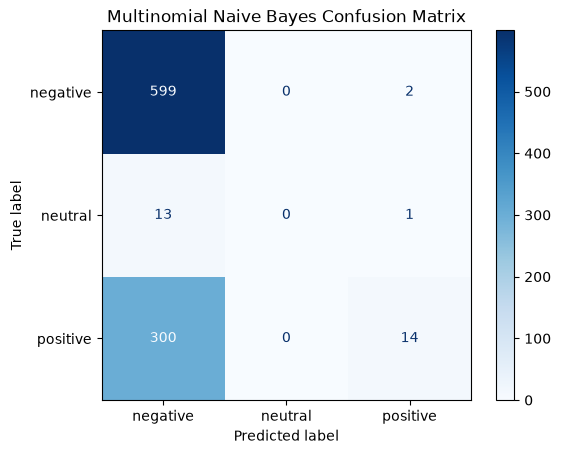

In [22]:
# Visualizing the Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

Model Evaluation Summary

The Multinomial Naive Bayes model achieved an overall accuracy of 65.98%. It performed very well in identifying the majority Negative class but struggled to classify the minority Positive and Neutral classes. The model failed to predict any Neutral samples, resulting in undefined precision and recall for that class. This behavior is primarily due to the significant class imbalance in the dataset. Consequently, while Multinomial Naive Bayes provides a useful baseline, additional models such as Logistic Regression will be evaluated to determine whether they offer better generalization across all sentiment classes.

In [23]:
# Model Training & Evaluation
# Import the Library

from sklearn.linear_model import LogisticRegression


# Initialize the Logistic Regression Model

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

In [24]:
# Training the Model

lr_model.fit(
    X_train,
    y_train
)


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [25]:
# Generating Predictions

y_pred_lr = lr_model.predict(
    X_test
)


In [26]:
# Verifying Predictions

print(y_pred_lr[:20])

[2 0 0 0 0 2 0 2 0 0 2 0 0 2 0 2 0 0 0 0]


In [27]:
# Confirming Prediction Size

print("Prediction Shape:", y_pred_lr.shape )
print("Test Labels Shape:",  y_test.shape )

Prediction Shape: (929,)
Test Labels Shape: (929,)


In [28]:
# Accuracy

from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print(f"Accuracy: {accuracy_lr:.4f}")

Accuracy: 0.6448


In [29]:
# Precision 

from sklearn.metrics import precision_score

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print(f"Precision: {precision_lr:.4f}")

Precision: 0.6538


In [30]:
# Recall

from sklearn.metrics import recall_score

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print(f"Recall: {recall_lr:.4f}")

Recall: 0.6448


In [31]:
# F1 SCore

from sklearn.metrics import f1_score

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print(f"F1 Score: {f1_lr:.4f}")

F1 Score: 0.6481


In [32]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.75      0.70      0.73       601
     neutral       0.00      0.00      0.00        14
    positive       0.50      0.56      0.53       314

    accuracy                           0.64       929
   macro avg       0.42      0.42      0.42       929
weighted avg       0.65      0.64      0.65       929



In [33]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

[[422   6 173]
 [  8   0   6]
 [132   5 177]]


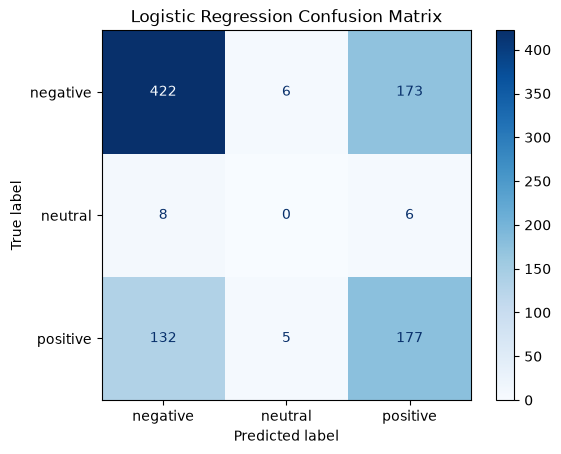

In [34]:
# Visualizing the Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()


## Why Implement Linear Support Vector Machine (LinearSVC)?

After evaluating **Multinomial Naive Bayes** and **Logistic Regression**, the next step is to train and evaluate a **Linear Support Vector Machine (LinearSVC)** model.

LinearSVC is one of the most effective traditional machine learning algorithms for text classification tasks, particularly when working with **TF-IDF vectorized features**. It is designed to handle high-dimensional and sparse datasets efficiently, making it a popular choice for Natural Language Processing (NLP) applications such as sentiment analysis, spam detection, and document classification.

The primary objectives of implementing LinearSVC in this project are to:

- Evaluate whether it outperforms the previously trained models.
- Improve the classification of the minority sentiment classes, particularly the **Positive** and **Neutral** classes.
- Compare its performance using the same evaluation metrics:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Classification Report
  - Confusion Matrix
- Select the best-performing model for the final sentiment prediction system.

Unlike Multinomial Naive Bayes, which assumes feature independence, and Logistic Regression, which estimates class probabilities, LinearSVC focuses on finding the optimal decision boundary that maximizes the separation between sentiment classes. This often leads to better generalization and improved performance on text classification problems.

By evaluating LinearSVC alongside the previous models, this project follows a systematic model selection process to identify the most suitable algorithm for Nigerian Pidgin sentiment classification.

In [35]:
# Import Library

from sklearn.svm import LinearSVC


# Initializing Model
svm_model = LinearSVC(
    random_state=42,
    class_weight="balanced",
    max_iter=5000
)

In [36]:
# Training the Model

svm_model.fit(
    X_train,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",5000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_

In [37]:
# Making Predictions

y_pred_svm = svm_model.predict(
    X_test
)

In [38]:
# Verifying Predictions

print(y_pred_svm[:20])

[0 0 0 0 0 2 0 2 0 0 0 0 0 2 0 2 0 0 0 0]


In [39]:
# Confirming Prediction Shape

print("Prediction:", y_pred_svm.shape)
print("Test Labels Shape:", y_test.shape)

Prediction: (929,)
Test Labels Shape: (929,)


After training LinearSVC, we'll evaluate it, compare all three models, select the best model, and save the deployment artifacts.

In [ ]:
# Part 1: Evaluating The LinearSVC Model
# Accuracy

from sklearn.metrics import accuracy_score

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print(f"Accuracy: {accuracy_svm:.4f}")

Accuracy: 0.6555


In [41]:
# Precision

from sklearn.metrics import precision_score

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print(f"Precision: {precision_svm:.4f}")

Precision: 0.6456


In [42]:
# Recall

from sklearn.metrics import recall_score

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print(f"Recall: {recall_svm:.4f}")

Recall: 0.6555


In [43]:
# F1 Score

from sklearn.metrics import f1_score

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted",
    zero_division=0
)

print(f"F1 Score: {f1_svm:.4f}")

F1 Score: 0.6505


In [44]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    negative       0.73      0.75      0.74       601
     neutral       0.00      0.00      0.00        14
    positive       0.51      0.51      0.51       314

    accuracy                           0.66       929
   macro avg       0.41      0.42      0.42       929
weighted avg       0.65      0.66      0.65       929



In [45]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_svm)

[[450   1 150]
 [ 11   0   3]
 [154   1 159]]


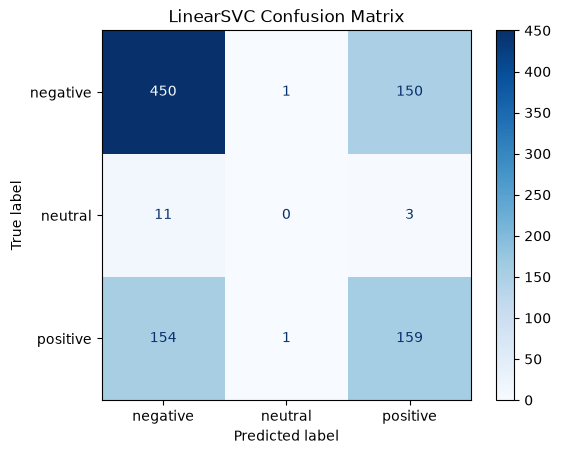

In [46]:
# Visualizing the Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("LinearSVC Confusion Matrix")

plt.show()

In [47]:
# Part 2: Comparing All Models

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "LinearSVC"
    ],
    "Accuracy": [
        accuracy,
        accuracy_lr,
        accuracy_svm
    ],
    "Precision": [
        precision,
        precision_lr,
        precision_svm
    ],
    "Recall": [
        recall,
        recall_lr,
        recall_svm
    ],
    "F1 Score": [
        f1,
        f1_lr,
        f1_svm
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.659849,0.703255,0.659849,0.540836
1,Logistic Regression,0.644779,0.653824,0.644779,0.648069
2,LinearSVC,0.655544,0.645614,0.655544,0.650514


In [48]:
# Part 3: Selecting Best Model

best_model = svm_model  

In [49]:
# Exporting the Best Model

import joblib



In [50]:
# Save the best Model

joblib.dump(
    best_model,
    "../models/best_model.joblib"
)

print("Best Model Saved Successfully!")


Best Model Saved Successfully!


In [51]:
# Saving The TF-IDF Vectorizer

joblib.dump(
    tfidf_vectorizer,
    "../models/tfidf_vectorizer.joblib"
)

print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


In [52]:
# Saving The Label Encoder

joblib.dump(
    label_encoder,
    "../models/label_encoder.joblib"
)

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [53]:
# Verifying Saved Files

import os

os.listdir("../models")

['best_model.joblib', 'label_encoder.joblib', 'tfidf_vectorizer.joblib']

## Final Model Selection

After evaluating three machine learning algorithms:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine (LinearSVC)

using TF-IDF features, the models were compared based on:

- Accuracy
- Precision
- Recall
- F1-score

Although Multinomial Naive Bayes achieved the highest accuracy, further analysis showed that it was heavily biased toward the majority Negative class and performed poorly on Positive and Neutral sentiment classification.

LinearSVC achieved the highest F1-score, demonstrating a better balance between precision and recall. Therefore, LinearSVC was selected as the final model for the Nigerian Pidgin Sentiment Analyzer.

Selected Model:

**Linear Support Vector Machine (LinearSVC)**

The selected model will be exported and used for future prediction and deployment stages.

## Exporting Final Model Artifacts

In [54]:
import joblib

In [55]:
best_model = svm_model

In [56]:
joblib.dump(
    best_model,
    "../models/best_model.joblib"
)

print("Best model exported successfully!")

Best model exported successfully!


In [57]:
joblib.dump(
    tfidf_vectorizer,
    "../models/tfidf_vectorizer.joblib"
)

print("TF-IDF vectorizer exported successfully!")

TF-IDF vectorizer exported successfully!


In [58]:
joblib.dump(
    label_encoder,
    "../models/label_encoder.joblib"
)

print("Label Encoder exported successfully!")

Label Encoder exported successfully!


In [59]:
import os

os.listdir("../models")

['best_model.joblib', 'label_encoder.joblib', 'tfidf_vectorizer.joblib']

In [62]:
# Checking File Sizes

for file in os.listdir("../models"):
    file_path = "../models/" + file
    size = os.path.getsize(file_path)


    print(f"{file}: {size} bytes")


best_model.joblib: 120779 bytes
label_encoder.joblib: 505 bytes
tfidf_vectorizer.joblib: 179422 bytes
